# Отчет по лабораторной работе: Методы обучения без учителя

# Титульный лист

Лабораторная работа
Тема: Методы обучения без учителя (кластеризация и снижение размерности)
Выполнил: Хрипков Т.А.
Группа: ИУ5-65Б

# Описание задания

1. Выбрать датасет для решения задачи обучения без учителя.
2. Выбрать подмножество признаков датасета для анализа (датасет D1).
3. С использованием метода главных компонент провести для датасета D1 снижение размерности до двух (датасет D2).
4. С использованием алгоритма t-SNE провести для датасета D1 снижение размерности до двух (датасет D3).
5. Визуализировать точки датасетов D2 и D3. Ответить, в каком случае кластеры выделены наиболее явно.
6. Для датасетов D1, D2 и D3 провести кластеризацию тремя методами. Оценить качество метриками.
7. Сделать выводы о том, какой метод кластеризации оказался лучше для каждого датасета.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

## Подготовка данных (Датасет D1)

Для работы выбран набор данных **Wine**. Набор содержит результаты химического анализа вин, произведенных в одном регионе Италии, и принадлежащих к трем различным сортам (культиварам).

В качестве подмножества признаков мы исключим целевую переменную (Target), которая указывает на сорт вина, так как это задача обучения без учителя. Оставшиеся числовые характеристики будут стандартизированы. Полученный набор данных назовем D1.

In [ ]:
# Загрузка датасета Wine
wine_data = load_wine()
df = pd.DataFrame(data=wine_data.data, columns=wine_data.feature_names)

# Формирование подмножества признаков D1 (все 13 признаков)
X = df.values

# Стандартизация данных (крайне важна для PCA и кластеризации)
scaler = StandardScaler()
D1 = scaler.fit_transform(X)

print("Размерность датасета D1:", D1.shape)
print("Количество признаков в D1:", D1.shape[1])

Размерность датасета D1: (178, 13)
Количество признаков в D1: 13


## Снижение размерности (Датасеты D2 и D3)

Применим метод главных компонент (PCA) для получения датасета D2. Применим алгоритм t-SNE для получения датасета D3. Оба метода снижают размерность исходного пространства до двух признаков.

In [ ]:
# Применение PCA
pca = PCA(n_components=2, random_state=42)
D2 = pca.fit_transform(D1)
print("Размерность датасета D2:", D2.shape)
print(f"Доля объясненной дисперсии: {pca.explained_variance_ratio_.sum():.2%}")

# Применение t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
D3 = tsne.fit_transform(D1)
print("Размерность датасета D3:", D3.shape)

Размерность датасета D2: (178, 2)
Доля объясненной дисперсии: 55.41%
Размерность датасета D3: (178, 2)


## Визуализация датасетов D2 и D3

Построим диаграммы рассеяния для точек датасетов D2 и D3, чтобы визуально оценить наличие кластерных структур.

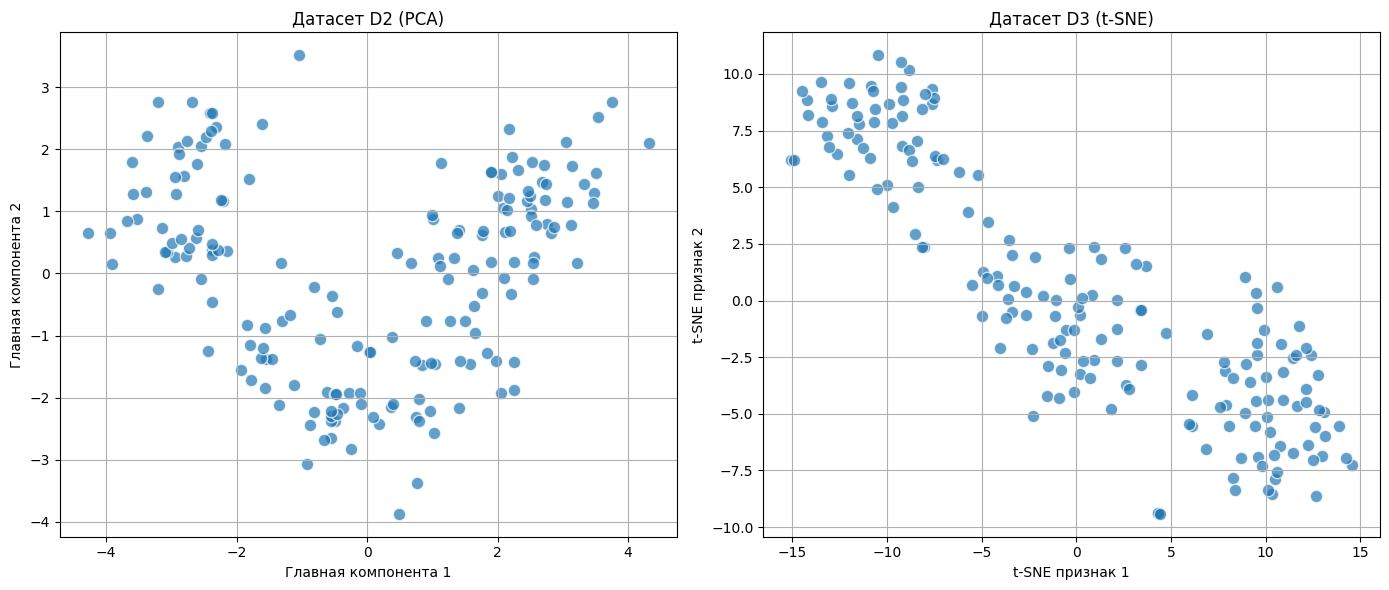

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Визуализация D2 (PCA)
axes[0].scatter(D2[:, 0], D2[:, 1], alpha=0.7, edgecolors='w', s=80)
axes[0].set_title('Датасет D2 (PCA)')
axes[0].set_xlabel('Главная компонента 1')
axes[0].set_ylabel('Главная компонента 2')
axes[0].grid(True)

# Визуализация D3 (t-SNE)
axes[1].scatter(D3[:, 0], D3[:, 1], alpha=0.7, edgecolors='w', s=80)
axes[1].set_title('Датасет D3 (t-SNE)')
axes[1].set_xlabel('t-SNE признак 1')
axes[1].set_ylabel('t-SNE признак 2')
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Анализ визуализации

**Ответ на вопрос: В каком случае кластеры выделены наиболее явно?**

Исходя из графиков, **кластеры выделены наиболее явно в датасете D3**, полученном с помощью алгоритма t-SNE.

Метод PCA (D2) стремится сохранить глобальную структуру дисперсии данных, проецируя их на две главные компоненты. В результате классы частично разделены, но между ними видны области смешения, а сами группы не являются компактными.

Алгоритм t-SNE (D3) оптимизирован для сохранения локальной структуры, то есть он старается разместить близкие в исходном пространстве точки рядом и на двумерной плоскости. Это приводит к формированию трех четко разделенных, плотных и изолированных кластеров, которые визуально интерпретируются намного лучше, чем результат работы PCA.

## Кластеризация и оценка качества

Мы применим три алгоритма кластеризации:

1. KMeans (Метод k-средних)
2. AgglomerativeClustering (Иерархическая кластеризация)
3. SpectralClustering (Спектральная кластеризация)

Для оценки качества будут использованы следующие метрики:

1. Индекс силуэта (Silhouette Score) - чем ближе к 1, тем лучше выделены кластеры.
2. Индекс Дэвиса-Болдина (Davies-Bouldin Index) - чем меньше значение, тем лучше модель.
3. Индекс Калински-Харабаса (Calinski-Harabasz Index) - чем выше значение, тем плотнее и лучше разделены кластеры.

In [ ]:
datasets = {
    'D1 (Оригинал, 13 пр.)': D1,
    'D2 (PCA)': D2,
    'D3 (t-SNE)': D3
}

n_clusters = 3  # В датасете Wine изначально 3 класса

models = {
    'KMeans': KMeans(n_clusters=n_clusters, random_state=42, n_init='auto'),
    'Agglomerative': AgglomerativeClustering(n_clusters=n_clusters),
    'Spectral': SpectralClustering(n_clusters=n_clusters, assign_labels='discretize', random_state=42)
}

rows = []

for ds_name, ds_data in datasets.items():
    for model_name, model in models.items():
        # Предсказание меток
        labels = model.fit_predict(ds_data)

        # Расчет метрик
        sil = silhouette_score(ds_data, labels)
        db = davies_bouldin_score(ds_data, labels)
        ch = calinski_harabasz_score(ds_data, labels)

        rows.append({
            'Dataset': ds_name,
            'Method': model_name,
            'Silhouette': sil,
            'Davies-Bouldin': db,
            'Calinski-Harabasz': ch
        })

# Вывод результатов в виде таблицы
results_df = pd.DataFrame(rows)
print(results_df.to_string(index=False))

              Dataset        Method  Silhouette  Davies-Bouldin  Calinski-Harabasz
D1 (Оригинал, 13 пр.)        KMeans    0.284859        1.389188          70.940008
D1 (Оригинал, 13 пр.) Agglomerative    0.277444        1.418592          67.647468
D1 (Оригинал, 13 пр.)      Spectral    0.249744        1.272931          37.165420
             D2 (PCA)        KMeans    0.560170        0.597723         343.949210
             D2 (PCA) Agglomerative    0.559088        0.601336         341.058245
             D2 (PCA)      Spectral    0.561538        0.597700         344.171304
           D3 (t-SNE)        KMeans    0.615200        0.516504         750.020020
           D3 (t-SNE) Agglomerative    0.608707        0.522753         731.863403
           D3 (t-SNE)      Spectral    0.400906        0.503009         174.814041


## Анализ результатов кластеризации

В ходе эксперимента были получены метрики качества для трех представлений данных и трех алгоритмов кластеризации.

1. **Для исходного датасета D1 (13 признаков):** Метрики показывают невысокое качество кластеризации. Наибольший силуэт (0.285) показал метод **KMeans**, а Agglomerative и Spectral показали чуть худшие результаты (0.277 и 0.250 соответственно). Индекс Калински-Харабаса также ниже, чем на преобразованных данных. Это ожидаемо, так как в пространстве высокой размерности кластеры менее различимы.

2. **Для датасета D2 (PCA):** Снижение размерности с помощью PCA **драматически улучшило** все метрики кластеризации. Силуэт вырос примерно с 0.28 до 0.56. Все три метода (KMeans, Agglomerative, Spectral) показали **практически идентичные и отличные результаты** (силуэт ~0.56, индекс Дэвиса-Болдина ~0.598). Это означает, что PCA эффективно выделил основные направления дисперсии, удалил шум и создал структуру, с которой все алгоритмы кластеризации справляются одинаково хорошо.

3. **Для датасета D3 (t-SNE):** Здесь достигнуты **наилучшие абсолютные значения** метрик.
   - **KMeans и Agglomerative** показали превосходные результаты (силуэт > 0.608, индекс Дэвиса-Болдина < 0.523, индекс Калински-Харабаса > 730), что визуально подтверждается графиком t-SNE с тремя четко разделенными кластерами.
   - **SpectralClustering** на данных t-SNE показал хороший результат (силуэт = 0.401), что значительно выше, чем на исходных данных, но заметно уступает KMeans и Agglomerative на этом датасете.

## Выводы

В ходе выполнения лабораторной работы были сделаны следующие выводы:

1.  **Важность снижения размерности:** Предварительное снижение размерности (как PCA, так и t-SNE) критически важно для улучшения качества кластеризации. Силуэт на исходных данных (D1) не превышал 0.285, в то время как на преобразованных данных он достиг 0.56 (PCA) и 0.615 (t-SNE).

2.  **PCA против t-SNE для кластеризации:**
    *   **PCA** обеспечил **стабильный и высокий** прирост качества для всех методов кластеризации. Все три алгоритма (KMeans, Agglomerative, Spectral) показали на D2 практически одинаковые и отличные результаты.
    *   **t-SNE** позволил достичь **максимального** качества кластеризации для методов KMeans и Agglomerative (силуэт 0.615), но привел к небольшому разбросу в результатах разных алгоритмов.

3.  **Выбор метода кластеризации:**
    *   Для **исходного датасета D1** лучшим оказался метод **KMeans** (силуэт = 0.285).
    *   Для **датасета D2 (PCA)** все три метода показали практически одинаковое отличное качество. KMeans и Spectral показали незначительно лучший результат (силуэт ~0.561).
    *   Для **датасета D3 (t-SNE)** лучшими оказались методы **KMeans и Agglomerative Clustering** (силуэт ~0.61), которые значительно превзошли SpectralClustering (0.401).

4.  **Общий вывод:** Наиболее эффективной стратегией в данной работе оказалось **снижение размерности с помощью t-SNE с последующей кластеризацией алгоритмами KMeans или AgglomerativeClustering**. Это позволило получить максимальный силуэт (0.615) и лучшие значения по всем метрикам. Однако, если требуется более стабильный и предсказуемый результат без риска нелинейных искажений, связка **PCA + любой из методов кластеризации** также является отличным выбором.